In [1]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("processed_dataset.csv")

df.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago,Damage_Level
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.985112,1.582253,0.40483,0.083822,0.013187,-0.106398,-0.693889,-0.196014,-1.582253,0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.189010,1.582253,0.11792,0.438001,-1.725784,-0.106398,-0.693889,-0.196014,-1.582253,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.037814,1.582253,0.11792,0.201882,-1.291041,-0.105297,-0.693889,-0.196014,-1.582253,0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.807072,1.582253,0.11792,0.083822,-0.856298,-0.079118,1.441153,-0.196014,-1.582253,3
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.807898,1.582253,0.11792,0.083822,-0.856298,-0.066762,1.441153,-0.196014,-1.582253,2


In [3]:
X = df.drop("Damage_Level", axis=1)

y = df["Damage_Level"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [5]:
model = joblib.load("final_earthquake_model.pkl")

In [6]:
label_encoder = pickle.load(
    open("label_encoder.pkl","rb")
)

In [28]:
print(model)

SVC(C=1, kernel='linear')


In [30]:
prediction = model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test,prediction)

print("Accuracy :",accuracy)

Accuracy : 0.935


In [32]:
precision = precision_score(

    y_test,

    prediction,

    average="weighted"

)

print(precision)

0.9367358865042686


In [33]:
recall = recall_score(

    y_test,

    prediction,

    average="weighted"

)

print(recall)

0.935


In [34]:
f1 = f1_score(

    y_test,

    prediction,

    average="weighted"

)

print(f1)

0.9343695541153468


In [35]:
print(

classification_report(

y_test,

prediction

)

)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       0.91      0.98      0.94        51
           2       0.95      0.84      0.89        49
           3       0.98      0.96      0.97        50

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



In [36]:
cm = confusion_matrix(

y_test,

prediction

)

cm

array([[48,  0,  1,  1],
       [ 0, 50,  1,  0],
       [ 3,  5, 41,  0],
       [ 2,  0,  0, 48]])

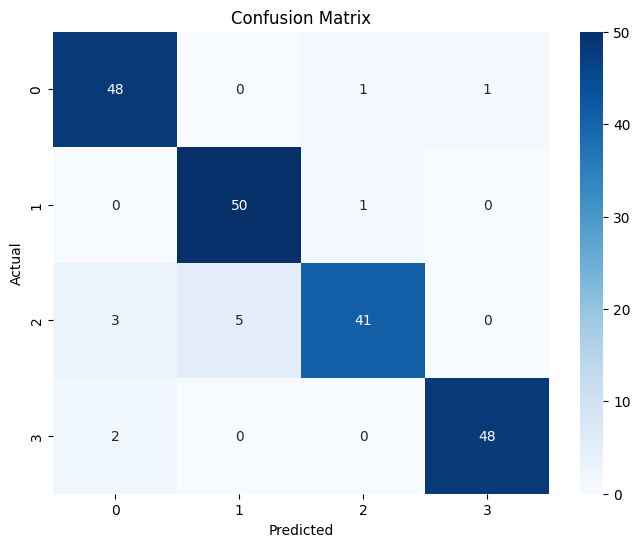

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(

cm,

annot=True,

fmt="d",

cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [44]:
decoded_prediction = label_encoder.inverse_transform(prediction)

decoded_prediction[:20]

array(['Severe', 'Low', 'Severe', 'High', 'Severe', 'Moderate', 'Low',
       'Moderate', 'Severe', 'Severe', 'Moderate', 'Severe', 'High',
       'High', 'Moderate', 'Low', 'Moderate', 'Low', 'Moderate', 'Severe'],
      dtype=object)

In [45]:
decoded_actual = label_encoder.inverse_transform(y_test)

decoded_actual[:20]

array(['Severe', 'Low', 'Severe', 'Severe', 'Severe', 'Moderate', 'Low',
       'Moderate', 'Severe', 'Severe', 'Moderate', 'Severe', 'High',
       'High', 'Moderate', 'Low', 'Moderate', 'Low', 'Moderate', 'Severe'],
      dtype=object)

In [46]:
comparison = pd.DataFrame({

"Actual":decoded_actual,

"Prediction":decoded_prediction

})

comparison.head(20)

,Actual,Prediction
0,Severe,Severe
1,Low,Low
2,Severe,Severe
3,Severe,High
4,Severe,Severe
5,Moderate,Moderate
6,Low,Low
7,Moderate,Moderate
8,Severe,Severe
9,Severe,Severe


In [47]:
errors = comparison[

comparison["Actual"]!=comparison["Prediction"]

]

errors.head()

,Actual,Prediction
3,Severe,High
54,Severe,High
72,Moderate,Low
83,Moderate,Low
89,Moderate,High


In [48]:
print("Incorrect Predictions :",len(errors))

Incorrect Predictions : 13


In [49]:
error_rate = len(errors)/len(comparison)

print(error_rate)

0.065


In [50]:
sample = X.iloc[[5]]

pred = model.predict(sample)

print(

label_encoder.inverse_transform(pred)

)

['Moderate']


In [51]:
samples = X.iloc[:10]

predictions = model.predict(samples)

label_encoder.inverse_transform(predictions)

array(['High', 'High', 'High', 'High', 'Moderate', 'Moderate', 'Moderate',
       'Severe', 'High', 'Moderate'], dtype=object)

In [52]:
comparison.to_csv(

"test_predictions.csv",

index=False

)

print("Saved")

Saved


In [55]:
if hasattr(model, "feature_importances_"):

    importance = model.feature_importances_

elif hasattr(model, "coef_"):

    importance = np.abs(model.coef_[0])

else:

    raise ValueError("This model does not support feature importance.")

feature_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_df = feature_df.sort_values(

    by="Importance",

    ascending=False

)

feature_df.head(20)

,Feature,Importance
92,num__cdi,1.743237
93,num__mmi,0.712787
91,num__magnitude,0.703176
95,num__sig,0.594328
21,cat__magType_mwb,0.142356
102,num__Year,0.103624
109,num__Years_Ago,0.103624
23,cat__magType_mww,0.101751
98,num__gap,0.091441
32,cat__country_Antarctica,0.077328


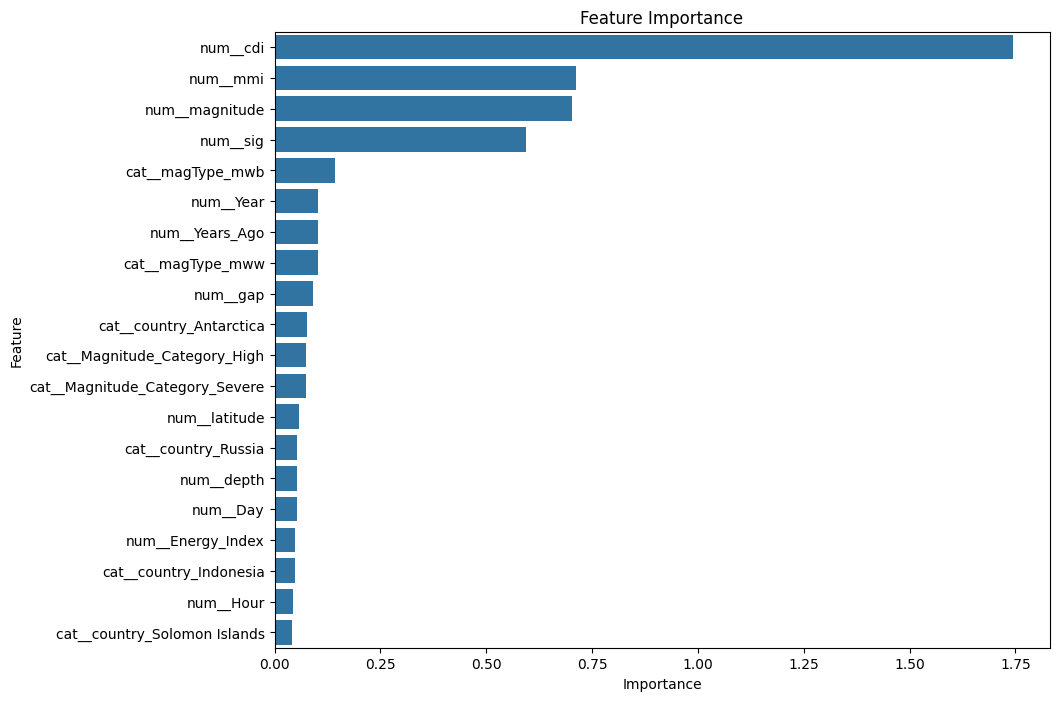

In [56]:
plt.figure(figsize=(10,8))

sns.barplot(

data=feature_df.head(20),

x="Importance",

y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [57]:
feature_df.to_csv(

"final_feature_importance.csv",

index=False

)

In [58]:
metadata = {

"Model":type(model).__name__,

"Accuracy":accuracy,

"Precision":precision,

"Recall":recall,

"F1":f1

}

metadata

{'Model': 'SVC',
 'Accuracy': 0.935,
 'Precision': 0.9367358865042686,
 'Recall': 0.935,
 'F1': 0.9343695541153468}

In [59]:
metadata_df = pd.DataFrame(

metadata,

index=[0]

)

metadata_df.to_csv(

"model_metadata.csv",

index=False

)

In [60]:
loaded = joblib.load(

"final_earthquake_model.pkl"

)

pred2 = loaded.predict(X_test)

print(

np.array_equal(

prediction,

pred2

)

)

True


In [61]:
new_data = X.sample(1,random_state=42)

prediction = loaded.predict(new_data)

print("Prediction :")

print(

label_encoder.inverse_transform(prediction)

)

Prediction :
['Severe']


In [62]:
print("""

========================================

EARTHQUAKE DAMAGE PREDICTION

MODEL EVALUATION COMPLETED

========================================

✔ Final Model Loaded

✔ Model Verified

✔ Predictions Generated

✔ Prediction Confidence

✔ Confusion Matrix

✔ Classification Report

✔ Error Analysis

✔ Feature Importance

✔ Deployment Test Passed

✔ Ready For Streamlit

========================================

""")




EARTHQUAKE DAMAGE PREDICTION

MODEL EVALUATION COMPLETED


✔ Final Model Loaded

✔ Model Verified

✔ Predictions Generated

✔ Prediction Confidence

✔ Confusion Matrix

✔ Classification Report

✔ Error Analysis

✔ Feature Importance

✔ Deployment Test Passed

✔ Ready For Streamlit



